In [15]:
# Cell 1. Imports y rutas

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
)

if Path.cwd().name == "notebooks":
    PROJECT_ROOT = Path.cwd().parent
else:
    PROJECT_ROOT = Path.cwd()

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
TABLES_DIR = PROJECT_ROOT / "tables" / "chapter5"
FIGURES_DIR = PROJECT_ROOT / "figures" / "chapter5"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [16]:
# Cell 2. Cargar datasets con regímenes (main y robust)

path_main = PROCESSED_DATA_DIR / "dataset_cap4_regimes_full.csv"
path_robust = PROCESSED_DATA_DIR / "dataset_cap4_regimes_full_robust.csv"

if not path_main.exists():
    raise FileNotFoundError(f"No existe: {path_main}")

if not path_robust.exists():
    raise FileNotFoundError(f"No existe: {path_robust}")

df_main = (
    pd.read_csv(path_main, parse_dates=["date"])
    .sort_values("date")
    .reset_index(drop=True)
)

df_robust = (
    pd.read_csv(path_robust, parse_dates=["date"])
    .sort_values("date")
    .reset_index(drop=True)
)

print("MAIN shape:", df_main.shape)
print("MAIN rango:", df_main["date"].min(), "->", df_main["date"].max())
print(df_main["sample_split_main"].value_counts(dropna=False))

print("\nROBUST shape:", df_robust.shape)
print("ROBUST rango:", df_robust["date"].min(), "->", df_robust["date"].max())
print(df_robust["sample_split_robust"].value_counts(dropna=False))

display(df_main.head())
display(df_robust.head())

MAIN shape: (6631, 10)
MAIN rango: 2000-03-28 00:00:00 -> 2026-04-23 00:00:00
sample_split_main
train    5274
test     1357
Name: count, dtype: int64

ROBUST shape: (6631, 10)
ROBUST rango: 2000-03-28 00:00:00 -> 2026-04-23 00:00:00
sample_split_robust
train    5017
test     1614
Name: count, dtype: int64


,date,sample_split_main,sample_split_robust,ret_1d,ewma_vol,cvar_95_60d,p_regime_0,p_regime_1,p_regime_2,regime
0,2000-03-28,train,train,0.004029,0.012799,-0.030112,0.574587,0.054909,0.370504,0
1,2000-03-29,train,train,-0.010083,0.012653,-0.025741,0.523537,0.039480,0.436983,0
2,2000-03-30,train,train,-0.021337,0.013334,-0.022476,0.062752,0.098099,0.839149,2
3,2000-03-31,train,train,0.008549,0.013097,-0.022476,0.104192,0.059555,0.836253,2
4,2000-04-03,train,train,-0.021049,0.013704,-0.022476,0.008784,0.085534,0.905682,2


,date,sample_split_main,sample_split_robust,ret_1d,ewma_vol,cvar_95_60d,p_regime_0,p_regime_1,p_regime_2,regime
0,2000-03-28,train,train,0.004029,0.012799,-0.030112,0.591948,0.352794,0.055258,0
1,2000-03-29,train,train,-0.010083,0.012653,-0.025741,0.542149,0.416526,0.041325,0
2,2000-03-30,train,train,-0.021337,0.013334,-0.022476,0.068335,0.823867,0.107798,1
3,2000-03-31,train,train,0.008549,0.013097,-0.022476,0.111819,0.821341,0.066840,1
4,2000-04-03,train,train,-0.021049,0.013704,-0.022476,0.009611,0.893041,0.097348,1


In [17]:
# Cell 3. Validaciones mínimas

required_cols_main = [
    "date",
    "sample_split_main",
    "ret_1d",
    "ewma_vol",
    "cvar_95_60d",
    "regime",
]

missing_main = [col for col in required_cols_main if col not in df_main.columns]
if missing_main:
    raise ValueError(f"Faltan columnas en df_main: {missing_main}")

splits_main = set(df_main["sample_split_main"].dropna().unique())
if not {"train", "test"}.issubset(splits_main):
    raise ValueError(f"df_main sin train/test: {splits_main}")

print("Validaciones MAIN OK")


required_cols_robust = [
    "date",
    "sample_split_robust",
    "ret_1d",
    "ewma_vol",
    "cvar_95_60d",
    "regime",
]

missing_robust = [col for col in required_cols_robust if col not in df_robust.columns]
if missing_robust:
    raise ValueError(f"Faltan columnas en df_robust: {missing_robust}")

splits_robust = set(df_robust["sample_split_robust"].dropna().unique())
if not {"train", "test"}.issubset(splits_robust):
    raise ValueError(f"df_robust sin train/test: {splits_robust}")

print("Validaciones ROBUST OK")

Validaciones MAIN OK
Validaciones ROBUST OK


In [18]:
# Cell 4. Cargar variables adicionales desde dataset_cap3_master

cap3_path = PROCESSED_DATA_DIR / "dataset_cap3_master.csv"

if cap3_path.exists():
    df_cap3 = pd.read_csv(cap3_path, parse_dates=["date"]).sort_values("date")

    extra_cols = [
        "date",
        "ret_20d",
        "ret_60d",
        "vol_20d",
        "vol_60d",
        "downside_vol_20d",
        "downside_vol_60d",
        "drawdown",
        "skew_60d",
    ]

    available_extra_cols = [col for col in extra_cols if col in df_cap3.columns]

    df_main = df_main.merge(
        df_cap3[available_extra_cols],
        on="date",
        how="left",
    )

    df_robust = df_robust.merge(
        df_cap3[available_extra_cols],
        on="date",
        how="left",
    )

    print("Variables adicionales incorporadas:", available_extra_cols)
else:
    print("No existe dataset_cap3_master.csv.")

print("Shape MAIN:", df_main.shape)
print("Shape ROBUST:", df_robust.shape)

display(df_main.head())
display(df_robust.head())

Variables adicionales incorporadas: ['date', 'ret_20d', 'ret_60d', 'vol_20d', 'vol_60d', 'downside_vol_20d', 'downside_vol_60d', 'drawdown', 'skew_60d']
Shape MAIN: (6631, 18)
Shape ROBUST: (6631, 18)


,date,sample_split_main,sample_split_robust,ret_1d,ewma_vol,cvar_95_60d,p_regime_0,p_regime_1,p_regime_2,regime,ret_20d,ret_60d,vol_20d,vol_60d,downside_vol_20d,downside_vol_60d,drawdown,skew_60d
0,2000-03-28,train,train,0.004029,0.012799,-0.030112,0.574587,0.054909,0.370504,0,-0.030224,0.050479,0.009648,0.015026,0.006057,0.008743,-0.047258,-0.022343
1,2000-03-29,train,train,-0.010083,0.012653,-0.025741,0.523537,0.039480,0.436983,0,-0.036557,0.075760,0.009827,0.014332,0.005956,0.007453,-0.056816,0.157888
2,2000-03-30,train,train,-0.021337,0.013334,-0.022476,0.062752,0.098099,0.839149,2,-0.071431,0.085554,0.010049,0.014009,0.006763,0.006668,-0.076727,0.276084
3,2000-03-31,train,train,0.008549,0.013097,-0.022476,0.104192,0.059555,0.836253,2,-0.065664,0.072314,0.010320,0.013785,0.006763,0.006668,-0.068800,0.285328
4,2000-04-03,train,train,-0.021049,0.013704,-0.022476,0.008784,0.085534,0.905682,2,-0.092331,0.044899,0.010820,0.014063,0.007224,0.006820,-0.088197,0.299276


,date,sample_split_main,sample_split_robust,ret_1d,ewma_vol,cvar_95_60d,p_regime_0,p_regime_1,p_regime_2,regime,ret_20d,ret_60d,vol_20d,vol_60d,downside_vol_20d,downside_vol_60d,drawdown,skew_60d
0,2000-03-28,train,train,0.004029,0.012799,-0.030112,0.591948,0.352794,0.055258,0,-0.030224,0.050479,0.009648,0.015026,0.006057,0.008743,-0.047258,-0.022343
1,2000-03-29,train,train,-0.010083,0.012653,-0.025741,0.542149,0.416526,0.041325,0,-0.036557,0.075760,0.009827,0.014332,0.005956,0.007453,-0.056816,0.157888
2,2000-03-30,train,train,-0.021337,0.013334,-0.022476,0.068335,0.823867,0.107798,1,-0.071431,0.085554,0.010049,0.014009,0.006763,0.006668,-0.076727,0.276084
3,2000-03-31,train,train,0.008549,0.013097,-0.022476,0.111819,0.821341,0.066840,1,-0.065664,0.072314,0.010320,0.013785,0.006763,0.006668,-0.068800,0.285328
4,2000-04-03,train,train,-0.021049,0.013704,-0.022476,0.009611,0.893041,0.097348,1,-0.092331,0.044899,0.010820,0.014063,0.007224,0.006820,-0.088197,0.299276


In [19]:
# Cell 5. Crear target predictivo regime_t_plus_1

df_main["regime_t_plus_1"] = df_main["regime"].shift(-1)
df_robust["regime_t_plus_1"] = df_robust["regime"].shift(-1)

df_model_main = df_main.dropna(subset=["regime_t_plus_1"]).copy()
df_model_robust = df_robust.dropna(subset=["regime_t_plus_1"]).copy()

df_model_main["regime_t_plus_1"] = df_model_main["regime_t_plus_1"].astype(int)
df_model_robust["regime_t_plus_1"] = df_model_robust["regime_t_plus_1"].astype(int)

print("MAIN shape:", df_model_main.shape)
print("MAIN distribución target:")
print(df_model_main["regime_t_plus_1"].value_counts().sort_index())

print("\nROBUST shape:", df_model_robust.shape)
print("ROBUST distribución target:")
print(df_model_robust["regime_t_plus_1"].value_counts().sort_index())

MAIN shape: (6630, 19)
MAIN distribución target:
regime_t_plus_1
0    2966
1     678
2    2986
Name: count, dtype: int64

ROBUST shape: (6630, 19)
ROBUST distribución target:
regime_t_plus_1
0    2995
1    2911
2     724
Name: count, dtype: int64


In [20]:
# Cell 6. Definir features sin leakage

candidate_features = [
    "ret_1d",
    "ret_20d",
    "ret_60d",
    "ewma_vol",
    "vol_20d",
    "vol_60d",
    "downside_vol_20d",
    "downside_vol_60d",
    "cvar_95_60d",
    "drawdown",
    "skew_60d",
]

feature_cols_main = [col for col in candidate_features if col in df_model_main.columns]
feature_cols_robust = [col for col in candidate_features if col in df_model_robust.columns]

if not feature_cols_main:
    raise ValueError("No hay features disponibles en MAIN.")

if not feature_cols_robust:
    raise ValueError("No hay features disponibles en ROBUST.")

print("Features MAIN:")
print(feature_cols_main)

print("\nFeatures ROBUST:")
print(feature_cols_robust)

Features MAIN:
['ret_1d', 'ret_20d', 'ret_60d', 'ewma_vol', 'vol_20d', 'vol_60d', 'downside_vol_20d', 'downside_vol_60d', 'cvar_95_60d', 'drawdown', 'skew_60d']

Features ROBUST:
['ret_1d', 'ret_20d', 'ret_60d', 'ewma_vol', 'vol_20d', 'vol_60d', 'downside_vol_20d', 'downside_vol_60d', 'cvar_95_60d', 'drawdown', 'skew_60d']


In [21]:
# Cell 7. Split train/test para ML — MAIN

df_train_main = df_model_main[df_model_main["sample_split_main"] == "train"].copy()
df_test_main = df_model_main[df_model_main["sample_split_main"] == "test"].copy()

df_train_main = df_train_main.dropna(subset=feature_cols_main + ["regime_t_plus_1"]).copy()
df_test_main = df_test_main.dropna(subset=feature_cols_main + ["regime_t_plus_1"]).copy()

if df_train_main.empty:
    raise ValueError("df_train_main está vacío tras limpieza.")

if df_test_main.empty:
    raise ValueError("df_test_main está vacío tras limpieza.")

X_train_main = df_train_main[feature_cols_main]
y_train_main = df_train_main["regime_t_plus_1"]

X_test_main = df_test_main[feature_cols_main]
y_test_main = df_test_main["regime_t_plus_1"]

print("MAIN X_train:", X_train_main.shape)
print("MAIN X_test:", X_test_main.shape)
print("MAIN train fechas:", df_train_main["date"].min(), "->", df_train_main["date"].max())
print("MAIN test fechas:", df_test_main["date"].min(), "->", df_test_main["date"].max())

print("\nMAIN distribución y_train:")
print(y_train_main.value_counts(normalize=True).sort_index())

print("\nMAIN distribución y_test:")
print(y_test_main.value_counts(normalize=True).sort_index())


# Cell 7. Split train/test para ML — ROBUST

df_train_robust = df_model_robust[df_model_robust["sample_split_robust"] == "train"].copy()
df_test_robust = df_model_robust[df_model_robust["sample_split_robust"] == "test"].copy()

df_train_robust = df_train_robust.dropna(subset=feature_cols_robust + ["regime_t_plus_1"]).copy()
df_test_robust = df_test_robust.dropna(subset=feature_cols_robust + ["regime_t_plus_1"]).copy()

if df_train_robust.empty:
    raise ValueError("df_train_robust está vacío tras limpieza.")

if df_test_robust.empty:
    raise ValueError("df_test_robust está vacío tras limpieza.")

X_train_robust = df_train_robust[feature_cols_robust]
y_train_robust = df_train_robust["regime_t_plus_1"]

X_test_robust = df_test_robust[feature_cols_robust]
y_test_robust = df_test_robust["regime_t_plus_1"]

print("\nROBUST X_train:", X_train_robust.shape)
print("ROBUST X_test:", X_test_robust.shape)
print("ROBUST train fechas:", df_train_robust["date"].min(), "->", df_train_robust["date"].max())
print("ROBUST test fechas:", df_test_robust["date"].min(), "->", df_test_robust["date"].max())

print("\nROBUST distribución y_train:")
print(y_train_robust.value_counts(normalize=True).sort_index())

print("\nROBUST distribución y_test:")
print(y_test_robust.value_counts(normalize=True).sort_index())

MAIN X_train: (5274, 11)
MAIN X_test: (1356, 11)
MAIN train fechas: 2000-03-28 00:00:00 -> 2020-12-31 00:00:00
MAIN test fechas: 2021-01-04 00:00:00 -> 2026-04-22 00:00:00

MAIN distribución y_train:
regime_t_plus_1
0    0.387941
1    0.122298
2    0.489761
Name: proportion, dtype: float64

MAIN distribución y_test:
regime_t_plus_1
0    0.678466
1    0.024336
2    0.297198
Name: proportion, dtype: float64

ROBUST X_train: (5017, 11)
ROBUST X_test: (1613, 11)
ROBUST train fechas: 2000-03-28 00:00:00 -> 2019-12-31 00:00:00
ROBUST test fechas: 2020-01-02 00:00:00 -> 2026-04-22 00:00:00

ROBUST distribución y_train:
regime_t_plus_1
0    0.403628
1    0.475982
2    0.120391
Name: proportion, dtype: float64

ROBUST distribución y_test:
regime_t_plus_1
0    0.601364
1    0.324241
2    0.074396
Name: proportion, dtype: float64


In [22]:
# Cell 8. Modelo baseline: Logistic Regression — MAIN

logit_model_main = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "model",
            LogisticRegression(
                class_weight="balanced",
                max_iter=2000,
                random_state=42,
            ),
        ),
    ]
)

logit_model_main.fit(X_train_main, y_train_main)

logit_pred_main = logit_model_main.predict(X_test_main)
logit_proba_main = logit_model_main.predict_proba(X_test_main)

print("Logistic Regression MAIN entrenado")


# Cell 8. Modelo baseline: Logistic Regression — ROBUST

logit_model_robust = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "model",
            LogisticRegression(
                class_weight="balanced",
                max_iter=2000,
                random_state=42,
            ),
        ),
    ]
)

logit_model_robust.fit(X_train_robust, y_train_robust)

logit_pred_robust = logit_model_robust.predict(X_test_robust)
logit_proba_robust = logit_model_robust.predict_proba(X_test_robust)

print("Logistic Regression ROBUST entrenado")

Logistic Regression MAIN entrenado
Logistic Regression ROBUST entrenado


In [23]:
# Cell 9. Modelo ML: Random Forest — MAIN

rf_model_main = RandomForestClassifier(
    n_estimators=500,
    max_depth=5,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

rf_model_main.fit(X_train_main, y_train_main)

rf_pred_main = rf_model_main.predict(X_test_main)
rf_proba_main = rf_model_main.predict_proba(X_test_main)

print("Random Forest MAIN entrenado")


# Cell 9. Modelo ML: Random Forest — ROBUST

rf_model_robust = RandomForestClassifier(
    n_estimators=500,
    max_depth=5,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

rf_model_robust.fit(X_train_robust, y_train_robust)

rf_pred_robust = rf_model_robust.predict(X_test_robust)
rf_proba_robust = rf_model_robust.predict_proba(X_test_robust)

print("Random Forest ROBUST entrenado")

Random Forest MAIN entrenado
Random Forest ROBUST entrenado


In [24]:
# Cell 10. Modelo ML avanzado: XGBoost

try:
    from xgboost import XGBClassifier

    xgb_available = True

except ImportError:
    xgb_available = False
    print("XGBoost no está instalado. Instala con: pip install xgboost")

In [25]:
# Cell 11. Entrenamiento XGBoost

if xgb_available:
    # MAIN
    xgb_model_main = XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1,
    )

    xgb_model_main.fit(X_train_main, y_train_main)

    xgb_pred_main = xgb_model_main.predict(X_test_main)
    xgb_proba_main = xgb_model_main.predict_proba(X_test_main)

    print("XGBoost MAIN entrenado")

    # ROBUST
    xgb_model_robust = XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1,
    )

    xgb_model_robust.fit(X_train_robust, y_train_robust)

    xgb_pred_robust = xgb_model_robust.predict(X_test_robust)
    xgb_proba_robust = xgb_model_robust.predict_proba(X_test_robust)

    print("XGBoost ROBUST entrenado")

XGBoost MAIN entrenado
XGBoost ROBUST entrenado


In [26]:
def evaluate_classifier(model_name, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    balanced_accuracy = balanced_accuracy_score(y_true, y_pred)

    metrics = {
        "model": model_name,
        "accuracy": accuracy,
        "balanced_accuracy": balanced_accuracy,
    }

    print(f"Modelo: {model_name}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Balanced accuracy: {balanced_accuracy:.4f}")
    print("\nClassification report:")
    print(classification_report(y_true, y_pred))

    return metrics

In [27]:
metrics_main = [
    evaluate_classifier("Logistic Regression MAIN", y_test_main, logit_pred_main),
    evaluate_classifier("Random Forest MAIN", y_test_main, rf_pred_main),
    evaluate_classifier("XGBoost MAIN", y_test_main, xgb_pred_main),
]

metrics_robust = [
    evaluate_classifier("Logistic Regression ROBUST", y_test_robust, logit_pred_robust),
    evaluate_classifier("Random Forest ROBUST", y_test_robust, rf_pred_robust),
    evaluate_classifier("XGBoost ROBUST", y_test_robust, xgb_pred_robust),
]

metrics_main_df = pd.DataFrame(metrics_main)
metrics_robust_df = pd.DataFrame(metrics_robust)

display(metrics_main_df)
display(metrics_robust_df)

Modelo: Logistic Regression MAIN
Accuracy: 0.9108
Balanced accuracy: 0.7766

Classification report:
              precision    recall  f1-score   support

           0       0.93      0.96      0.95       920
           1       0.82      0.55      0.65        33
           2       0.87      0.82      0.85       403

    accuracy                           0.91      1356
   macro avg       0.87      0.78      0.82      1356
weighted avg       0.91      0.91      0.91      1356

Modelo: Random Forest MAIN
Accuracy: 0.9019
Balanced accuracy: 0.7625

Classification report:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       920
           1       0.61      0.52      0.56        33
           2       0.85      0.82      0.83       403

    accuracy                           0.90      1356
   macro avg       0.80      0.76      0.78      1356
weighted avg       0.90      0.90      0.90      1356

Modelo: XGBoost MAIN
Accuracy: 0.9100
Balanc

,model,accuracy,balanced_accuracy
0,Logistic Regression MAIN,0.910767,0.776613
1,Random Forest MAIN,0.901917,0.762526
2,XGBoost MAIN,0.910029,0.778597


,model,accuracy,balanced_accuracy
0,Logistic Regression ROBUST,0.887787,0.824116
1,Random Forest ROBUST,0.897706,0.861174
2,XGBoost ROBUST,0.889027,0.819010


In [28]:
# Cell 12. Matrices de confusión — MAIN

labels_main = sorted(y_train_main.unique())

logit_cm_main = confusion_matrix(y_test_main, logit_pred_main, labels=labels_main)
rf_cm_main = confusion_matrix(y_test_main, rf_pred_main, labels=labels_main)

logit_cm_main_df = pd.DataFrame(
    logit_cm_main,
    index=[f"true_{label}" for label in labels_main],
    columns=[f"pred_{label}" for label in labels_main],
)

rf_cm_main_df = pd.DataFrame(
    rf_cm_main,
    index=[f"true_{label}" for label in labels_main],
    columns=[f"pred_{label}" for label in labels_main],
)

print("Confusion Matrix - Logistic Regression (MAIN)")
display(logit_cm_main_df)

print("Confusion Matrix - Random Forest (MAIN)")
display(rf_cm_main_df)


# Cell 12. Matrices de confusión — ROBUST

labels_robust = sorted(y_train_robust.unique())

logit_cm_robust = confusion_matrix(y_test_robust, logit_pred_robust, labels=labels_robust)
rf_cm_robust = confusion_matrix(y_test_robust, rf_pred_robust, labels=labels_robust)

logit_cm_robust_df = pd.DataFrame(
    logit_cm_robust,
    index=[f"true_{label}" for label in labels_robust],
    columns=[f"pred_{label}" for label in labels_robust],
)

rf_cm_robust_df = pd.DataFrame(
    rf_cm_robust,
    index=[f"true_{label}" for label in labels_robust],
    columns=[f"pred_{label}" for label in labels_robust],
)

print("Confusion Matrix - Logistic Regression (ROBUST)")
display(logit_cm_robust_df)

print("Confusion Matrix - Random Forest (ROBUST)")
display(rf_cm_robust_df)

Confusion Matrix - Logistic Regression (MAIN)


,pred_0,pred_1,pred_2
true_0,886,0,34
true_1,1,18,14
true_2,68,4,331


Confusion Matrix - Random Forest (MAIN)


,pred_0,pred_1,pred_2
true_0,875,0,45
true_1,2,17,14
true_2,61,11,331


Confusion Matrix - Logistic Regression (ROBUST)


,pred_0,pred_1,pred_2
true_0,921,49,0
true_1,70,426,27
true_2,1,34,85


Confusion Matrix - Random Forest (ROBUST)


,pred_0,pred_1,pred_2
true_0,917,53,0
true_1,60,434,29
true_2,2,21,97


In [29]:
# Confusion Matrix - XGBoost (MAIN)

xgb_cm_main = confusion_matrix(y_test_main, xgb_pred_main, labels=labels_main)

xgb_cm_main_df = pd.DataFrame(
    xgb_cm_main,
    index=[f"true_{label}" for label in labels_main],
    columns=[f"pred_{label}" for label in labels_main],
)

print("Confusion Matrix - XGBoost (MAIN)")
display(xgb_cm_main_df)

# Confusion Matrix - XGBoost (ROBUST)

xgb_cm_robust = confusion_matrix(y_test_robust, xgb_pred_robust, labels=labels_robust)

xgb_cm_robust_df = pd.DataFrame(
    xgb_cm_robust,
    index=[f"true_{label}" for label in labels_robust],
    columns=[f"pred_{label}" for label in labels_robust],
)

print("Confusion Matrix - XGBoost (ROBUST)")
display(xgb_cm_robust_df)

Confusion Matrix - XGBoost (MAIN)


,pred_0,pred_1,pred_2
true_0,860,0,60
true_1,1,17,15
true_2,43,3,357


Confusion Matrix - XGBoost (ROBUST)


,pred_0,pred_1,pred_2
true_0,899,71,0
true_1,48,456,19
true_2,1,40,79


In [30]:
# Cell 13. Selección del modelo final — MAIN

selected_model_name_main = metrics_main_df.sort_values(
    "balanced_accuracy", ascending=False
).iloc[0]["model"]

if "Logistic Regression" in selected_model_name_main:
    selected_model_main = logit_model_main
    selected_pred_main = logit_pred_main
    selected_proba_main = logit_proba_main

elif "Random Forest" in selected_model_name_main:
    selected_model_main = rf_model_main
    selected_pred_main = rf_pred_main
    selected_proba_main = rf_proba_main

elif "XGBoost" in selected_model_name_main:
    selected_model_main = xgb_model_main
    selected_pred_main = xgb_pred_main
    selected_proba_main = xgb_proba_main

print("Modelo seleccionado MAIN:", selected_model_name_main)


# Cell 13. Selección del modelo final — ROBUST

selected_model_name_robust = metrics_robust_df.sort_values(
    "balanced_accuracy", ascending=False
).iloc[0]["model"]

if "Logistic Regression" in selected_model_name_robust:
    selected_model_robust = logit_model_robust
    selected_pred_robust = logit_pred_robust
    selected_proba_robust = logit_proba_robust

elif "Random Forest" in selected_model_name_robust:
    selected_model_robust = rf_model_robust
    selected_pred_robust = rf_pred_robust
    selected_proba_robust = rf_proba_robust

elif "XGBoost" in selected_model_name_robust:
    selected_model_robust = xgb_model_robust
    selected_pred_robust = xgb_pred_robust
    selected_proba_robust = xgb_proba_robust

print("Modelo seleccionado ROBUST:", selected_model_name_robust)

Modelo seleccionado MAIN: XGBoost MAIN
Modelo seleccionado ROBUST: Random Forest ROBUST


Importancia de variables — MAIN


,feature,importance
3,ewma_vol,0.385008
4,vol_20d,0.272718
5,vol_60d,0.070418
1,ret_20d,0.052568
6,downside_vol_20d,0.042750
0,ret_1d,0.035276
8,cvar_95_60d,0.031802
7,downside_vol_60d,0.031217
2,ret_60d,0.030654
9,drawdown,0.025664


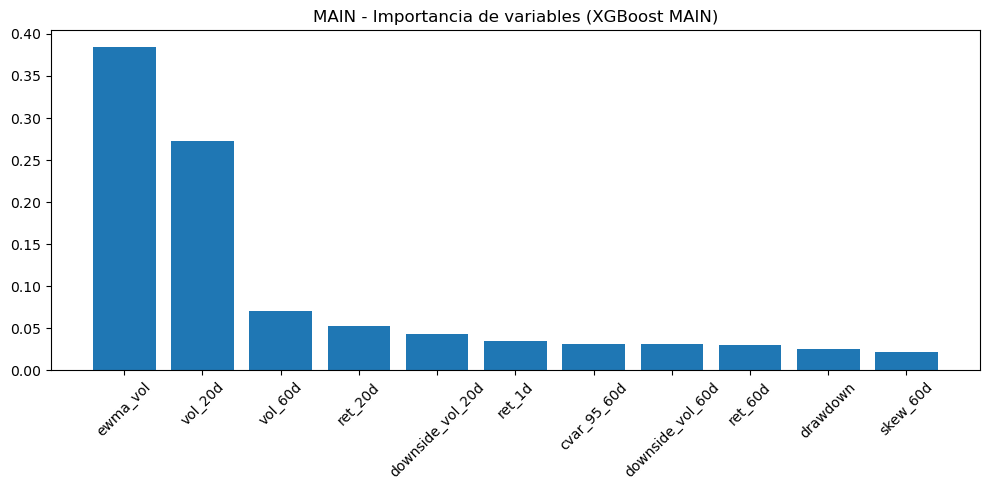


Importancia de variables — ROBUST


,feature,importance
3,ewma_vol,0.338452
4,vol_20d,0.264215
5,vol_60d,0.098589
6,downside_vol_20d,0.094983
8,cvar_95_60d,0.091387
7,downside_vol_60d,0.045046
2,ret_60d,0.028016
1,ret_20d,0.022610
9,drawdown,0.006501
0,ret_1d,0.005637


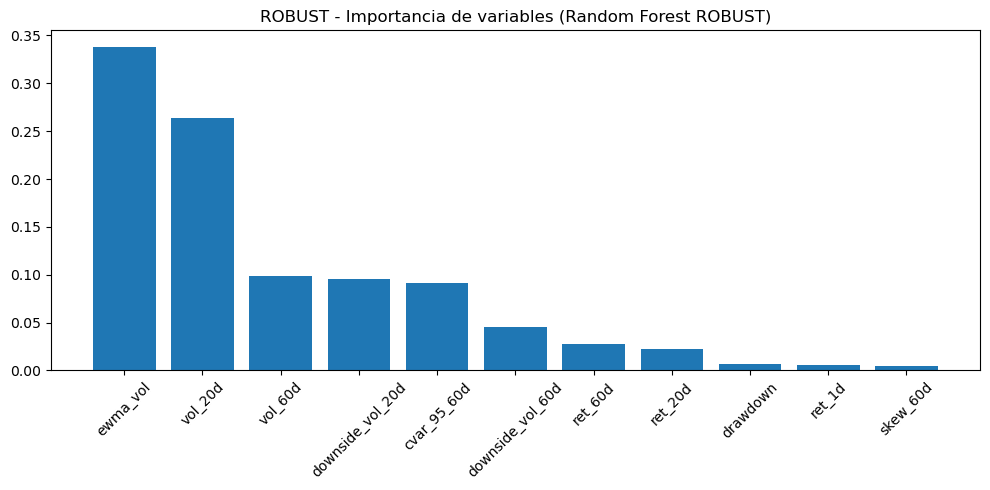

In [31]:
# Cell 14. Importancia de variables — MAIN

if "Random Forest" in selected_model_name_main or "XGBoost" in selected_model_name_main:

    importances_main = selected_model_main.feature_importances_

    feature_importance_main = pd.DataFrame(
        {
            "feature": feature_cols_main,
            "importance": importances_main,
        }
    ).sort_values("importance", ascending=False)

    print("Importancia de variables — MAIN")
    display(feature_importance_main)

    plt.figure(figsize=(10, 5))
    plt.bar(feature_importance_main["feature"], feature_importance_main["importance"])
    plt.title(f"MAIN - Importancia de variables ({selected_model_name_main})")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

else:
    print("MAIN: modelo sin feature_importances_")


# ROBUST

if "Random Forest" in selected_model_name_robust or "XGBoost" in selected_model_name_robust:

    importances_robust = selected_model_robust.feature_importances_

    feature_importance_robust = pd.DataFrame(
        {
            "feature": feature_cols_robust,
            "importance": importances_robust,
        }
    ).sort_values("importance", ascending=False)

    print("\nImportancia de variables — ROBUST")
    display(feature_importance_robust)

    plt.figure(figsize=(10, 5))
    plt.bar(feature_importance_robust["feature"], feature_importance_robust["importance"])
    plt.title(f"ROBUST - Importancia de variables ({selected_model_name_robust})")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

else:
    print("ROBUST: modelo sin feature_importances_")

In [32]:
# Cell 15. Construir dataset de predicciones OOS — MAIN

df_predictions_main = df_test_main[
    [
        "date",
        "sample_split_main",
        "ret_1d",
        "regime",
        "regime_t_plus_1",
    ]
].copy()

df_predictions_main["regime_pred"] = selected_pred_main

classes_main = selected_model_main.classes_

for i, cls in enumerate(classes_main):
    df_predictions_main[f"proba_{cls}"] = selected_proba_main[:, i]

print("Shape predicciones MAIN:", df_predictions_main.shape)
display(df_predictions_main.head())


# Cell 15. Construir dataset de predicciones OOS — ROBUST

df_predictions_robust = df_test_robust[
    [
        "date",
        "sample_split_robust",
        "ret_1d",
        "regime",
        "regime_t_plus_1",
    ]
].copy()

df_predictions_robust["regime_pred"] = selected_pred_robust

classes_robust = selected_model_robust.classes_

for i, cls in enumerate(classes_robust):
    df_predictions_robust[f"proba_{cls}"] = selected_proba_robust[:, i]

print("Shape predicciones ROBUST:", df_predictions_robust.shape)
display(df_predictions_robust.head())

Shape predicciones MAIN: (1356, 9)


,date,sample_split_main,ret_1d,regime,regime_t_plus_1,regime_pred,proba_0,proba_1,proba_2
5274,2021-01-04,test,0.003153,2,0,2,0.030707,0.000937,0.968356
5275,2021-01-05,test,-0.000951,0,2,2,0.074493,0.000889,0.924618
5276,2021-01-06,test,0.031483,2,2,2,0.002597,0.002011,0.995391
5277,2021-01-07,test,0.004242,2,2,2,0.008457,0.001637,0.989905
5278,2021-01-08,test,0.002608,2,2,2,0.009446,0.001635,0.988919


Shape predicciones ROBUST: (1613, 9)


,date,sample_split_robust,ret_1d,regime,regime_t_plus_1,regime_pred,proba_0,proba_1,proba_2
5017,2020-01-02,test,0.014761,0,0,0,0.970611,0.029375,0.000014
5018,2020-01-03,test,-0.004613,0,0,0,0.975589,0.024397,0.000014
5019,2020-01-06,test,-0.004749,0,0,0,0.977271,0.022715,0.000014
5020,2020-01-07,test,-0.002200,0,0,0,0.978117,0.021869,0.000014
5021,2020-01-08,test,0.001210,0,0,0,0.978589,0.021397,0.000014


In [33]:
# Cell 16. Validaciones

if df_predictions_main.empty:
    raise ValueError("df_predictions_main está vacío")

if df_predictions_main["regime_pred"].isna().any():
    raise ValueError("Hay NaNs en regime_pred MAIN")

if df_predictions_robust.empty:
    raise ValueError("df_predictions_robust está vacío")

if df_predictions_robust["regime_pred"].isna().any():
    raise ValueError("Hay NaNs en regime_pred ROBUST")

print("Validaciones MAIN OK")
print(df_predictions_main["regime_pred"].value_counts())

print("\nValidaciones ROBUST OK")
print(df_predictions_robust["regime_pred"].value_counts())

Validaciones MAIN OK
regime_pred
0    904
2    432
1     20
Name: count, dtype: int64

Validaciones ROBUST OK
regime_pred
0    979
1    508
2    126
Name: count, dtype: int64


In [34]:
# Cell 17. Exportar

output_path_main = PROCESSED_DATA_DIR / "dataset_cap5_regime_predictions.csv"
metrics_path_main = TABLES_DIR / "regime_prediction_metrics.csv"

output_path_robust = PROCESSED_DATA_DIR / "dataset_cap5_regime_predictions_robust.csv"
metrics_path_robust = TABLES_DIR / "regime_prediction_metrics_robust.csv"

df_predictions_main.to_csv(output_path_main, index=False)
metrics_main_df.to_csv(metrics_path_main, index=False)

df_predictions_robust.to_csv(output_path_robust, index=False)
metrics_robust_df.to_csv(metrics_path_robust, index=False)

print("Exportado MAIN:", output_path_main)
print("Exportado MAIN:", metrics_path_main)

print("Exportado ROBUST:", output_path_robust)
print("Exportado ROBUST:", metrics_path_robust)

Exportado MAIN: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/data/processed/dataset_cap5_regime_predictions.csv
Exportado MAIN: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/tables/chapter5/regime_prediction_metrics.csv
Exportado ROBUST: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/data/processed/dataset_cap5_regime_predictions_robust.csv
Exportado ROBUST: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/tables/chapter5/regime_prediction_metrics_robust.csv


In [35]:
# Cell 18. Resumen final

print("Notebook 05 completado")

print("\nMAIN")
print("Modelo final:", selected_model_name_main)
print("Observaciones OOS:", df_predictions_main.shape[0])
print(
    "Accuracy:",
    metrics_main_df.set_index("model").loc[selected_model_name_main, "accuracy"],
)
print(
    "Balanced accuracy:",
    metrics_main_df.set_index("model").loc[selected_model_name_main, "balanced_accuracy"],
)

print("\nROBUST")
print("Modelo final:", selected_model_name_robust)
print("Observaciones OOS:", df_predictions_robust.shape[0])
print(
    "Accuracy:",
    metrics_robust_df.set_index("model").loc[selected_model_name_robust, "accuracy"],
)
print(
    "Balanced accuracy:",
    metrics_robust_df.set_index("model").loc[selected_model_name_robust, "balanced_accuracy"],
)

Notebook 05 completado

MAIN
Modelo final: XGBoost MAIN
Observaciones OOS: 1356
Accuracy: 0.9100294985250738
Balanced accuracy: 0.7785967344172113

ROBUST
Modelo final: Random Forest ROBUST
Observaciones OOS: 1613
Accuracy: 0.8977061376317421
Balanced accuracy: 0.8611740246485274


## Resultados del Notebook 05 — Predicción de regímenes de mercado

En este notebook se ha abordado la predicción del régimen de mercado en \( t+1 \) a partir de variables de riesgo observadas en \( t \), utilizando modelos de Machine Learning. El objetivo no es predecir retornos, sino anticipar cambios en el entorno de riesgo para poder adaptar la exposición de la cartera.

Se han evaluado tres modelos: Logistic Regression, Random Forest y XGBoost, comparando su rendimiento tanto en el split principal (MAIN) como en el split de robustez (ROBUST).

---

## Resultados en el split MAIN

El modelo con mejor rendimiento ha sido XGBoost:

- Accuracy ≈ 0.91  
- Balanced accuracy ≈ 0.78  

El modelo muestra un buen comportamiento general, con alta precisión en los regímenes más frecuentes (bajo e intermedio). Sin embargo, se observa una limitación clara en el régimen de estrés:

- Bajo número de observaciones (muy desbalanceado)  
- Recall reducido (~0.52)  
- Confusión frecuente con el régimen intermedio  

Esto implica que, aunque el modelo es globalmente preciso, tiene dificultades para anticipar correctamente episodios extremos, que son precisamente los más relevantes desde el punto de vista de gestión del riesgo.

---

## Resultados en el split ROBUST

En el split alternativo, el modelo seleccionado ha sido Random Forest:

- Accuracy ≈ 0.90  
- Balanced accuracy ≈ 0.86  

Aquí se observa una mejora significativa en balanced accuracy respecto al caso MAIN, lo que indica un mejor equilibrio en la clasificación entre regímenes.

Las diferencias clave respecto a MAIN:

- El dataset está menos desbalanceado  
- Mayor representación del régimen intermedio  
- Mejor recall en todos los regímenes, incluido el de estrés  

Esto se traduce en una clasificación más estable y homogénea entre clases.

---

## Comparación MAIN vs ROBUST

Las diferencias entre ambos splits reflejan la sensibilidad del modelo a la distribución temporal de los datos:

- En MAIN (test 2021–2026), el régimen de estrés es muy poco frecuente → mayor dificultad de predicción  
- En ROBUST (test 2020–2026), se incluyen periodos de alta volatilidad → mejor aprendizaje de estados extremos  

A pesar de estas diferencias:

- Los modelos mantienen niveles de accuracy elevados en ambos casos  
- La estructura de resultados es consistente  
- La capacidad predictiva es estable  

Esto refuerza la robustez del enfoque.

---

## Importancia de variables

En los modelos basados en árboles, las variables más relevantes son:

- Volatilidad (EWMA, vol_20d, vol_60d)  
- Medidas de downside risk  
- CVaR  

Esto es coherente con la teoría financiera, donde los cambios en volatilidad y riesgo extremo son los principales determinantes de los regímenes de mercado.

---

## Conclusión

Los resultados muestran que:

- El modelo captura adecuadamente la dinámica de los regímenes  
- La metodología es estable frente a cambios en el split temporal  
- La señal generada es suficientemente informativa para ser utilizada en la construcción de estrategias adaptativas (Notebook 06)

Este bloque valida la viabilidad de utilizar modelos supervisados para anticipar cambios en el riesgo de mercado.

In [37]:
display(metrics_main_df)
display(metrics_robust_df)

print(metrics_main_df.columns.tolist())
print(metrics_robust_df.columns.tolist())

,model,accuracy,balanced_accuracy
0,Logistic Regression MAIN,0.910767,0.776613
1,Random Forest MAIN,0.901917,0.762526
2,XGBoost MAIN,0.910029,0.778597


,model,accuracy,balanced_accuracy
0,Logistic Regression ROBUST,0.887787,0.824116
1,Random Forest ROBUST,0.897706,0.861174
2,XGBoost ROBUST,0.889027,0.819010


['model', 'accuracy', 'balanced_accuracy']
['model', 'accuracy', 'balanced_accuracy']


In [38]:
# Tablas académicas de desempeño predictivo — MAIN y ROBUST

from sklearn.metrics import recall_score

# MAIN
stress_regime_main = 1

stress_recall_main = {
    "Logistic Regression MAIN": recall_score(
        y_test_main, logit_pred_main, labels=[stress_regime_main], average="macro", zero_division=0
    ),
    "Random Forest MAIN": recall_score(
        y_test_main, rf_pred_main, labels=[stress_regime_main], average="macro", zero_division=0
    ),
    "XGBoost MAIN": recall_score(
        y_test_main, xgb_pred_main, labels=[stress_regime_main], average="macro", zero_division=0
    ),
}

prediction_metrics_main_academic = metrics_main_df.copy()

prediction_metrics_main_academic["Stress Recall"] = (
    prediction_metrics_main_academic["model"].map(stress_recall_main)
)

prediction_metrics_main_academic["Model"] = (
    prediction_metrics_main_academic["model"]
    .str.replace(" MAIN", "", regex=False)
)

prediction_metrics_main_academic = prediction_metrics_main_academic[
    [
        "Model",
        "accuracy",
        "balanced_accuracy",
        "Stress Recall",
    ]
].rename(
    columns={
        "accuracy": "Accuracy",
        "balanced_accuracy": "Balanced Accuracy",
    }
)

prediction_metrics_main_academic = prediction_metrics_main_academic.round(3)

display(prediction_metrics_main_academic)


# ROBUST
stress_regime_robust = 2

stress_recall_robust = {
    "Logistic Regression ROBUST": recall_score(
        y_test_robust, logit_pred_robust, labels=[stress_regime_robust], average="macro", zero_division=0
    ),
    "Random Forest ROBUST": recall_score(
        y_test_robust, rf_pred_robust, labels=[stress_regime_robust], average="macro", zero_division=0
    ),
    "XGBoost ROBUST": recall_score(
        y_test_robust, xgb_pred_robust, labels=[stress_regime_robust], average="macro", zero_division=0
    ),
}

prediction_metrics_robust_academic = metrics_robust_df.copy()

prediction_metrics_robust_academic["Stress Recall"] = (
    prediction_metrics_robust_academic["model"].map(stress_recall_robust)
)

prediction_metrics_robust_academic["Model"] = (
    prediction_metrics_robust_academic["model"]
    .str.replace(" ROBUST", "", regex=False)
)

prediction_metrics_robust_academic = prediction_metrics_robust_academic[
    [
        "Model",
        "accuracy",
        "balanced_accuracy",
        "Stress Recall",
    ]
].rename(
    columns={
        "accuracy": "Accuracy",
        "balanced_accuracy": "Balanced Accuracy",
    }
)

prediction_metrics_robust_academic = prediction_metrics_robust_academic.round(3)

display(prediction_metrics_robust_academic)

,Model,Accuracy,Balanced Accuracy,Stress Recall
0,Logistic Regression,0.911,0.777,0.545
1,Random Forest,0.902,0.763,0.515
2,XGBoost,0.910,0.779,0.515


,Model,Accuracy,Balanced Accuracy,Stress Recall
0,Logistic Regression,0.888,0.824,0.708
1,Random Forest,0.898,0.861,0.808
2,XGBoost,0.889,0.819,0.658


In [39]:
# Exportar tablas académicas de desempeño predictivo

prediction_metrics_main_academic.to_csv(
    TABLES_DIR / "regime_prediction_metrics.csv",
    index=False,
)

prediction_metrics_robust_academic.to_csv(
    TABLES_DIR / "regime_prediction_metrics_robust.csv",
    index=False,
)

prediction_metrics_main_academic.to_latex(
    TABLES_DIR / "regime_prediction_metrics.tex",
    index=False,
    escape=False,
    float_format="%.3f",
)

prediction_metrics_robust_academic.to_latex(
    TABLES_DIR / "regime_prediction_metrics_robust.tex",
    index=False,
    escape=False,
    float_format="%.3f",
)

print("Exportado:", TABLES_DIR / "regime_prediction_metrics.csv")
print("Exportado:", TABLES_DIR / "regime_prediction_metrics.tex")
print("Exportado:", TABLES_DIR / "regime_prediction_metrics_robust.csv")
print("Exportado:", TABLES_DIR / "regime_prediction_metrics_robust.tex")

Exportado: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/tables/chapter5/regime_prediction_metrics.csv
Exportado: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/tables/chapter5/regime_prediction_metrics.tex
Exportado: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/tables/chapter5/regime_prediction_metrics_robust.csv
Exportado: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/tables/chapter5/regime_prediction_metrics_robust.tex


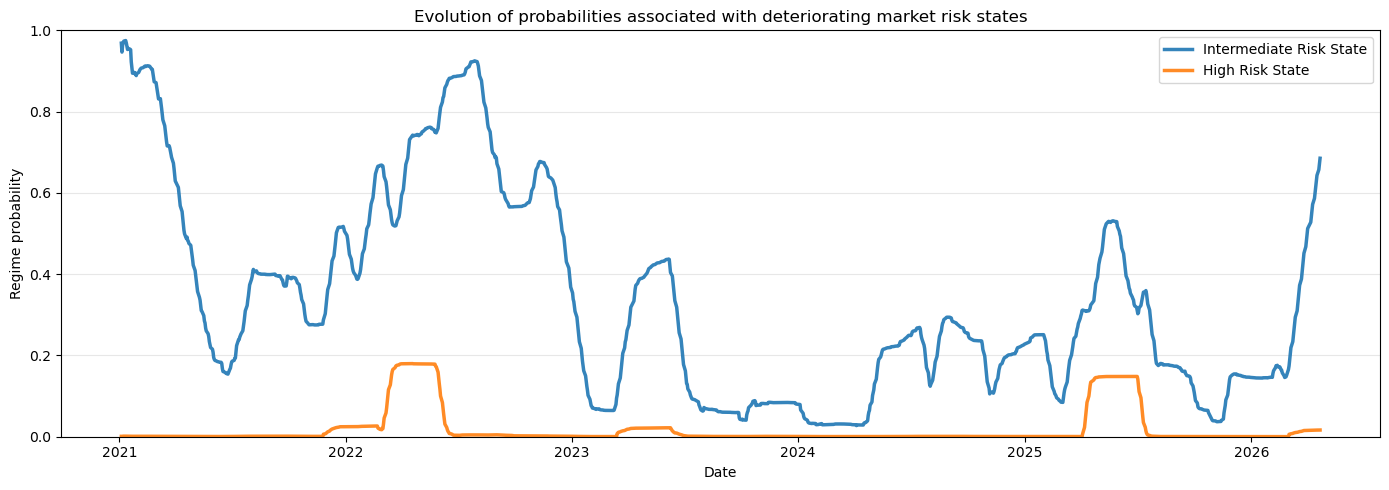

Figura guardada: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/figures/chapter5/predicted_regime_probabilities.png


In [43]:
# Figura final — probabilidades asociadas a estados de deterioro del riesgo

import matplotlib.pyplot as plt
import pandas as pd

pred_main = pd.read_csv(
    PROCESSED_DATA_DIR / "dataset_cap5_regime_predictions.csv"
)

pred_main["date"] = pd.to_datetime(pred_main["date"])

# MAIN:
# 0 = Low Risk
# 2 = Medium Risk
# 1 = High Risk

smoothing_window = 60

pred_main["intermediate_risk_smooth"] = (
    pred_main["proba_2"]
    .rolling(window=smoothing_window, min_periods=1)
    .mean()
)

pred_main["high_risk_smooth"] = (
    pred_main["proba_1"]
    .rolling(window=smoothing_window, min_periods=1)
    .mean()
)

plt.figure(figsize=(14, 5))

plt.plot(
    pred_main["date"],
    pred_main["intermediate_risk_smooth"],
    label="Intermediate Risk State",
    linewidth=2.5,
    alpha=0.9,
)

plt.plot(
    pred_main["date"],
    pred_main["high_risk_smooth"],
    label="High Risk State",
    linewidth=2.5,
    alpha=0.9,
)

plt.title(
    "Evolution of probabilities associated with deteriorating market risk states"
)

plt.xlabel("Date")

plt.ylabel("Regime probability")

plt.ylim(0, 1)

plt.grid(axis="y", alpha=0.3)

plt.legend(loc="upper right")

plt.tight_layout()

fig_path = FIGURES_DIR / "predicted_regime_probabilities.png"

plt.savefig(
    fig_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Figura guardada:", fig_path)